# 12 — K-Nearest Neighbors Classifier (Classification Track — Part A)
**23CSE301 Machine Learning — Capstone, Review 1**

**Dataset:** Employee promotion (`train.csv`) **Target:** `is_promoted` (1 = promoted, 0 = not promoted)

| Block | Rubric section |
|---|---|
| 1 | Section A — Dataset & EDA |
| 2 | Section B — Preprocessing & Feature Engineering |
| 3 | Section D — Classification Track, Part A (K-Nearest Neighbors Classifier) |

KNN has no real training step: it **stores** the employees and, for a new one, finds the **k most similar** employees (smallest distance) and predicts the **majority class** among them, optionally weighting closer neighbours more. **k** controls smoothness and, because it works on distances, **feature scaling is critical**. With only 8.5% promotions, small k matters: a promoted employee's neighbourhood is usually dominated by non-promoted ones. This notebook also contains the **final comparison of all 5 Part-A classifiers**.

---
# BLOCK 1 — Dataset & EDA (Section A)

In [1]:
# ============================================================
# BLOCK 1 : DATASET & EDA
# ============================================================

# ---- 1.0 Imports & global settings ----
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
RANDOM_STATE = 42                      # fixed seed for reproducibility (guideline 7.1)
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="colorblind")   # colour-blind-friendly palette (guideline 7.3)
pd.set_option("display.max_columns", 50)

DATA_PATH = "../data/train.csv"        # change if your file is somewhere else
TARGET = "is_promoted"

**Note on the dataset files:** the original download has `train.csv` (labelled) and `test.csv` (**no `is_promoted` column**).
Because the test file has no labels, it cannot be used to measure accuracy, so all 5 classifiers use `train.csv`
split 80:20 with stratification.

## A1 — Dataset loading & audit

In [2]:
# ---- 1.1 Load the dataset ----
df = pd.read_csv(DATA_PATH)

# employee_id is a unique identifier, not a predictive feature -> drop it
df = df.drop(columns=["employee_id"], errors="ignore")

# strip stray spaces from text columns
for col in df.select_dtypes(include=["object", "string"]).columns:
    df[col] = df[col].astype("object").where(df[col].isna(), df[col].astype(str).str.strip())

print("Shape (rows, columns):", df.shape)
df.head()

Shape (rows, columns): (54808, 12)


,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
0,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,0,49,0
1,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,60,0
2,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,50,0
3,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,50,0
4,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,73,0


In [3]:
# ---- 1.2 Data types, missing values & duplicates ----
audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isnull().sum(),
    "missing_%": (df.isnull().mean() * 100).round(2),
    "n_unique": df.nunique(),
})
print("Duplicate rows:", df.duplicated().sum())
audit

Duplicate rows: 219


,dtype,missing_count,missing_%,n_unique
department,object,0,0.00,9
region,object,0,0.00,34
education,object,2409,4.40,3
gender,object,0,0.00,2
recruitment_channel,object,0,0.00,3
no_of_trainings,int64,0,0.00,10
age,int64,0,0.00,41
previous_year_rating,float64,4124,7.52,5
length_of_service,int64,0,0.00,35
awards_won?,int64,0,0.00,2


In [4]:
# ---- 1.3 Statistical summary of numeric columns ----
df.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_trainings,54808.0,1.253011,0.609264,1.0,1.0,1.0,1.0,10.0
age,54808.0,34.803915,7.660169,20.0,29.0,33.0,39.0,60.0
previous_year_rating,50684.0,3.329256,1.259993,1.0,3.0,3.0,4.0,5.0
length_of_service,54808.0,5.865512,4.265094,1.0,3.0,5.0,7.0,37.0
awards_won?,54808.0,0.023172,0.150450,0.0,0.0,0.0,0.0,1.0
avg_training_score,54808.0,63.386750,13.371559,39.0,51.0,60.0,76.0,99.0
is_promoted,54808.0,0.085170,0.279137,0.0,0.0,0.0,0.0,1.0


is_promoted
0    50140
1     4668
Name: count, dtype: int64

Class balance (%):
is_promoted
0    91.48
1     8.52
Name: proportion, dtype: float64

Imbalance ratio  ->  1 promoted for every 10.7 not promoted


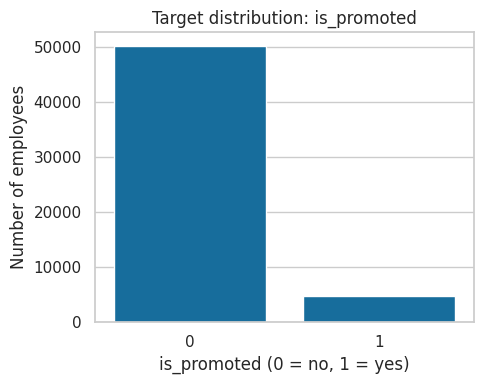

In [5]:
# ---- 1.4 Class distribution of the target (class imbalance check) ----
counts = df[TARGET].value_counts().sort_index()
print(counts)
print("\nClass balance (%):")
print((df[TARGET].value_counts(normalize=True) * 100).round(2))
print("\nImbalance ratio  ->  1 promoted for every %.1f not promoted" % (counts[0] / counts[1]))

plt.figure(figsize=(5, 4))
sns.countplot(x=df[TARGET])
plt.title("Target distribution: is_promoted")
plt.xlabel("is_promoted (0 = no, 1 = yes)"); plt.ylabel("Number of employees")
plt.tight_layout(); plt.show()

**📝 What this shows:** Only 8.5% of employees were promoted, so a model that says 'nobody is promoted' would already be 91.5% accurate.

## A2 — EDA visualisations

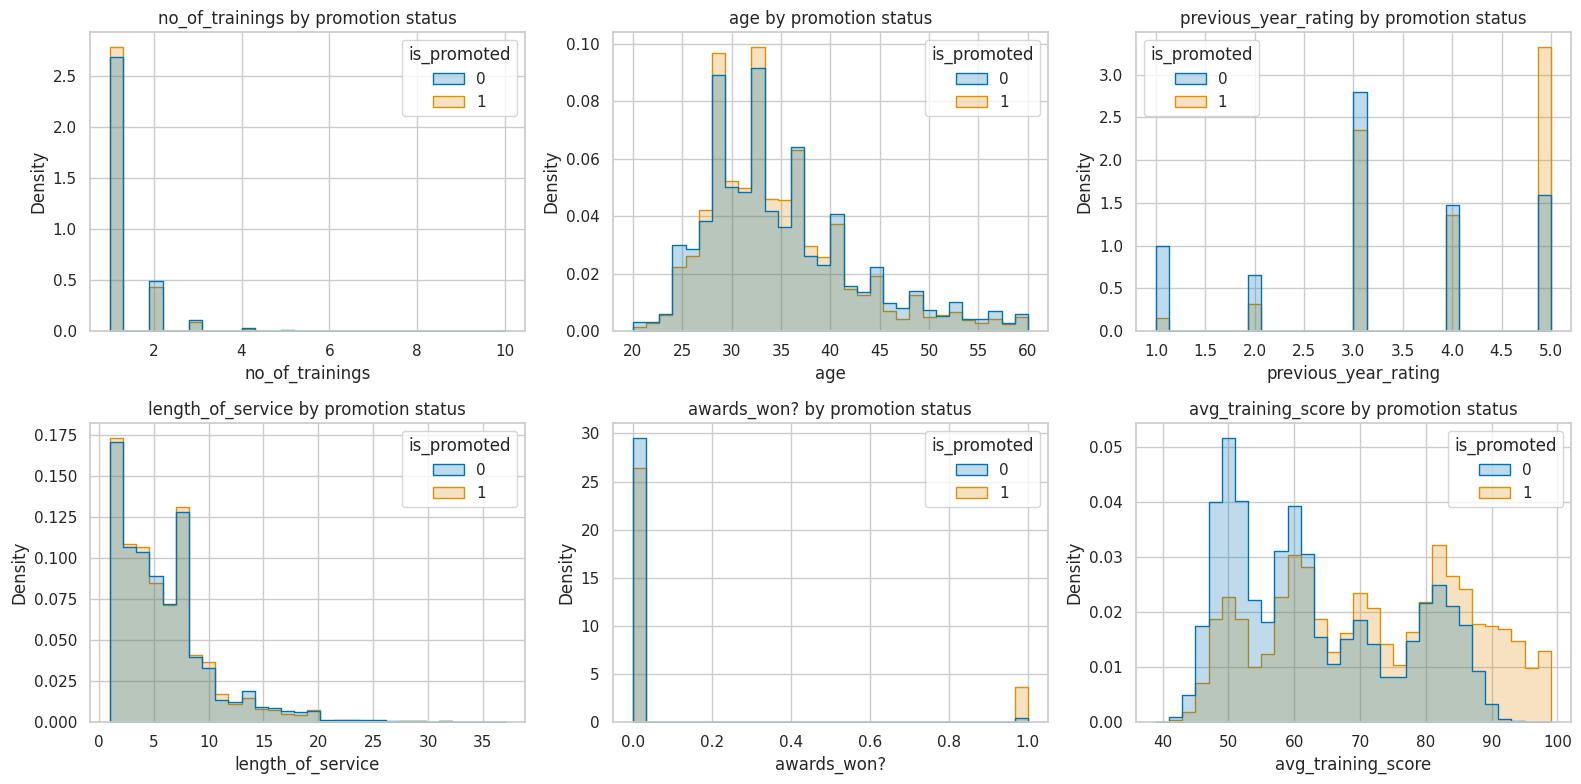

In [6]:
# ---- 1.5 Distribution of EACH numeric feature, split by class ----
num_features = ["no_of_trainings", "age", "previous_year_rating", "length_of_service",
                "awards_won?", "avg_training_score"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, num_features):
    sns.histplot(data=df, x=col, hue=TARGET, bins=30, element="step", stat="density",
                 common_norm=False, ax=ax)
    ax.set_title(f"{col} by promotion status")
    ax.set_xlabel(col); ax.set_ylabel("Density")
plt.tight_layout(); plt.show()

**📝 What this shows:** Promoted employees have a much higher training score (71 vs 63) and far more awards; age and service length look the same for both groups.

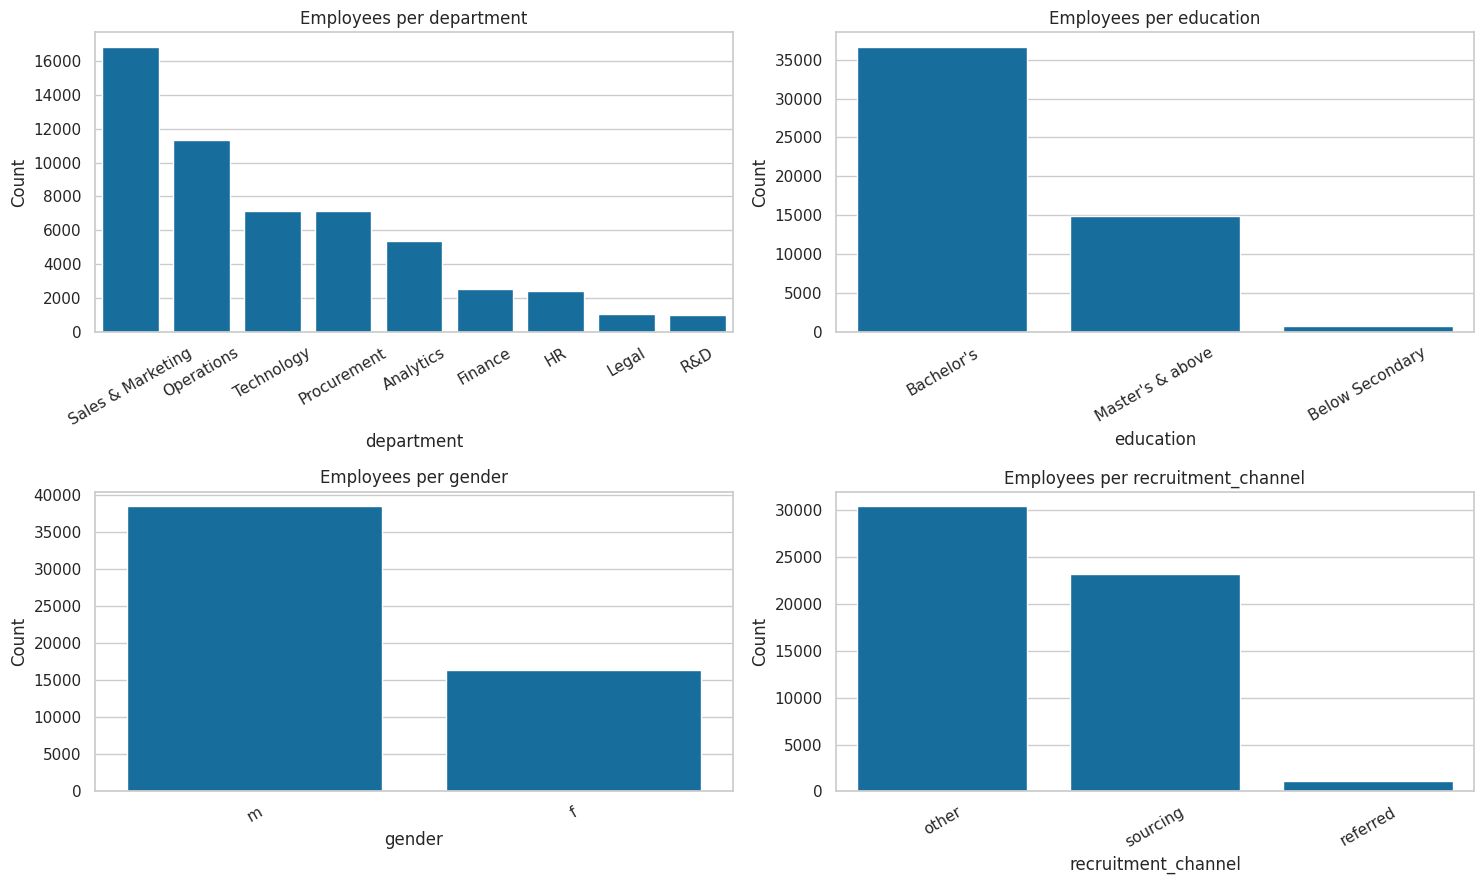

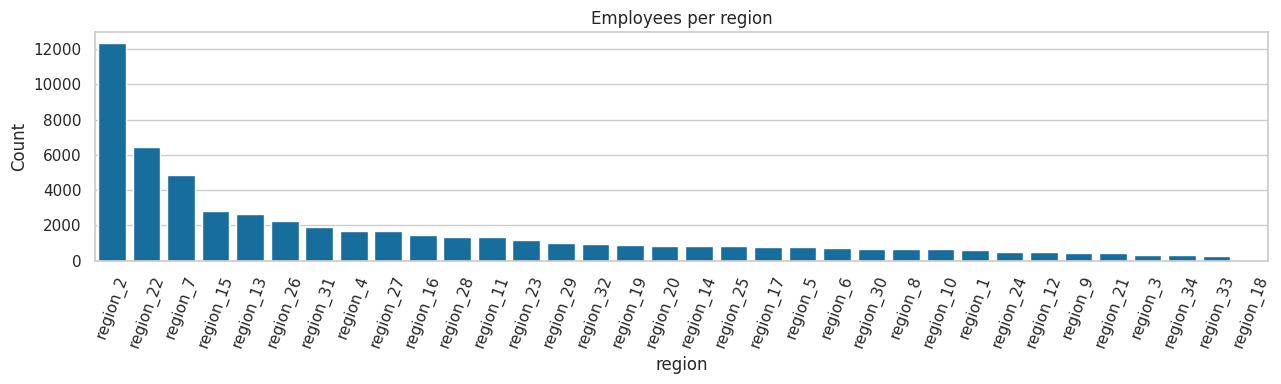

In [7]:
# ---- 1.6 Distribution of EACH categorical feature ----
cat_features = ["department", "region", "education", "gender", "recruitment_channel"]

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for ax, col in zip(axes.flat, ["department", "education", "gender", "recruitment_channel"]):
    sns.countplot(data=df, x=col, order=df[col].value_counts().index, ax=ax)
    ax.set_title(f"Employees per {col}")
    ax.set_xlabel(col); ax.set_ylabel("Count"); ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

plt.figure(figsize=(13, 4))
sns.countplot(data=df, x="region", order=df["region"].value_counts().index)
plt.title("Employees per region"); plt.xlabel("region"); plt.ylabel("Count"); plt.xticks(rotation=70)
plt.tight_layout(); plt.show()

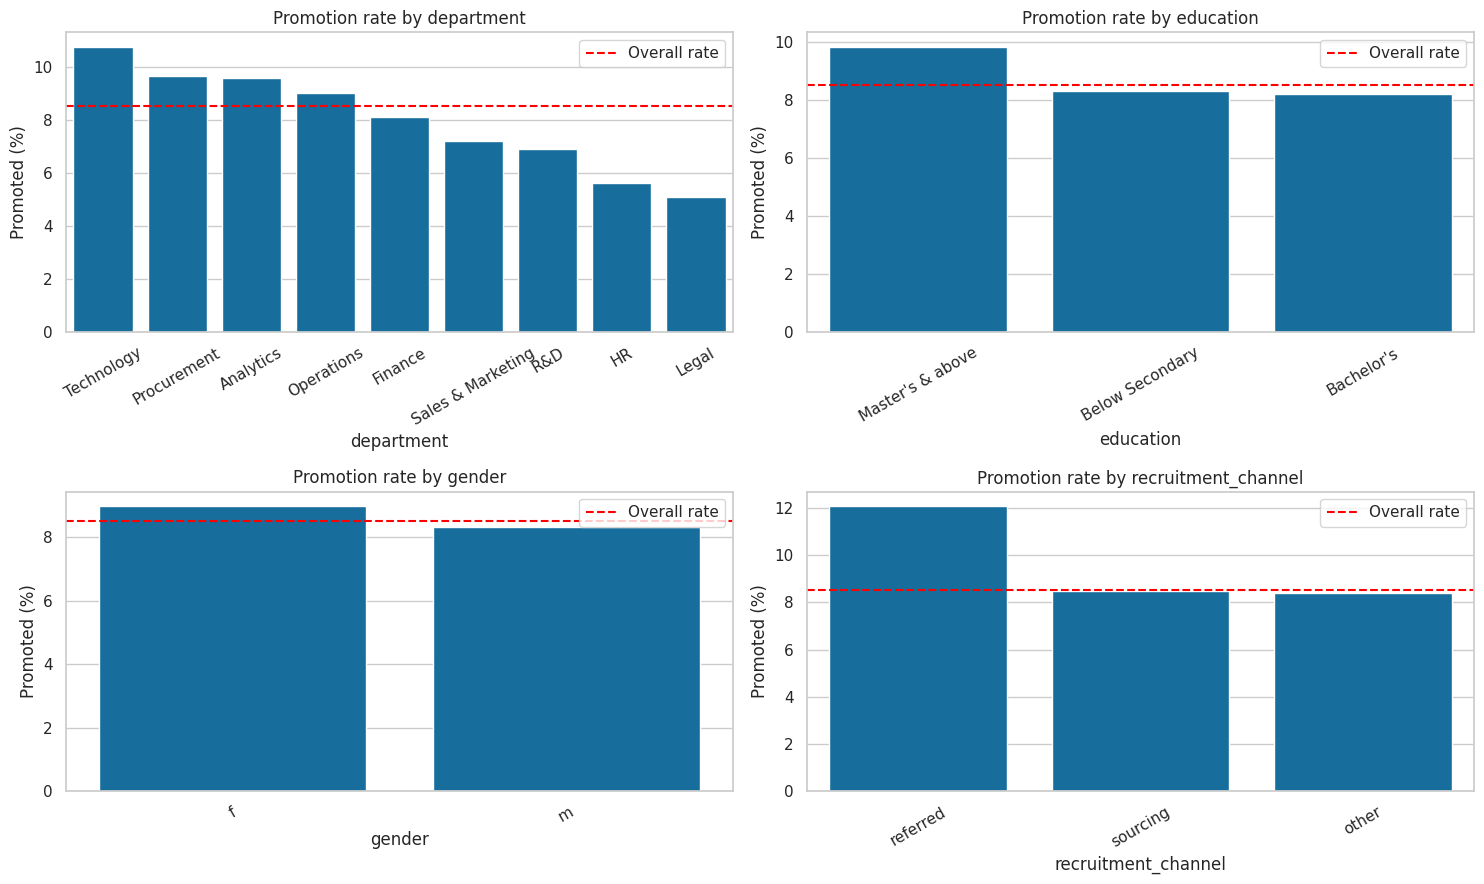

In [8]:
# ---- 1.7 Promotion RATE per category (the class distribution within each group) ----
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for ax, col in zip(axes.flat, ["department", "education", "gender", "recruitment_channel"]):
    rate = df.groupby(col, dropna=False)[TARGET].mean().sort_values(ascending=False) * 100
    sns.barplot(x=rate.index.astype(str), y=rate.values, ax=ax)
    ax.axhline(df[TARGET].mean() * 100, color="red", linestyle="--", label="Overall rate")
    ax.set_title(f"Promotion rate by {col}")
    ax.set_xlabel(col); ax.set_ylabel("Promoted (%)"); ax.tick_params(axis="x", rotation=30); ax.legend()
plt.tight_layout(); plt.show()

**📝 What this shows:** Technology promotes the most (10.8%) and Legal the least (5.1%), and referred employees do best at 12.1%.

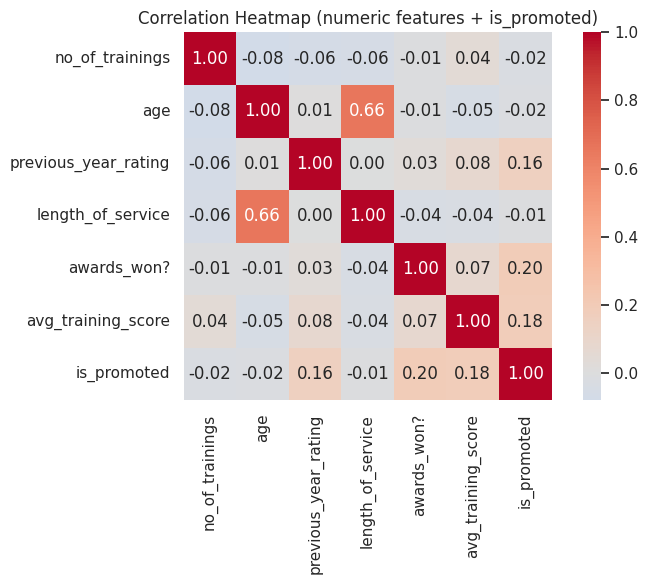

In [9]:
# ---- 1.8 Correlation heatmap (numeric features + target) ----
plt.figure(figsize=(8, 6))
corr = df[num_features + [TARGET]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap (numeric features + is_promoted)")
plt.tight_layout(); plt.show()

**📝 What this shows:** Awards (0.196) and training score (0.181) link most to promotion, but all links are weak; age and service length are strongly tied to each other (0.66).

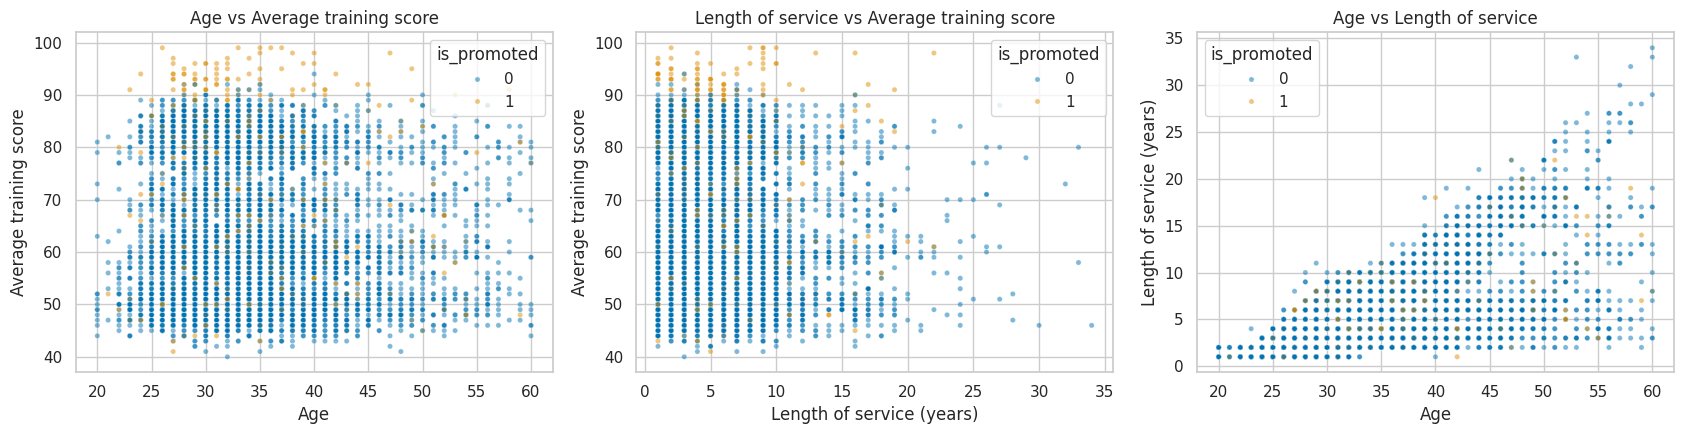

In [10]:
# ---- 1.9 Scatter plots: feature relationships coloured by the target ----
sample = df.sample(6000, random_state=RANDOM_STATE)     # sample so the plots stay readable

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
sns.scatterplot(data=sample, x="age", y="avg_training_score", hue=TARGET, alpha=0.5, s=14, ax=axes[0])
axes[0].set_title("Age vs Average training score")
axes[0].set_xlabel("Age"); axes[0].set_ylabel("Average training score")

sns.scatterplot(data=sample, x="length_of_service", y="avg_training_score", hue=TARGET, alpha=0.5, s=14, ax=axes[1])
axes[1].set_title("Length of service vs Average training score")
axes[1].set_xlabel("Length of service (years)"); axes[1].set_ylabel("Average training score")

sns.scatterplot(data=sample, x="age", y="length_of_service", hue=TARGET, alpha=0.5, s=14, ax=axes[2])
axes[2].set_title("Age vs Length of service")
axes[2].set_xlabel("Age"); axes[2].set_ylabel("Length of service (years)")
plt.tight_layout(); plt.show()

**📝 What this shows:** The two groups overlap almost completely, and only training score separates them, with promoted people sitting near the top.

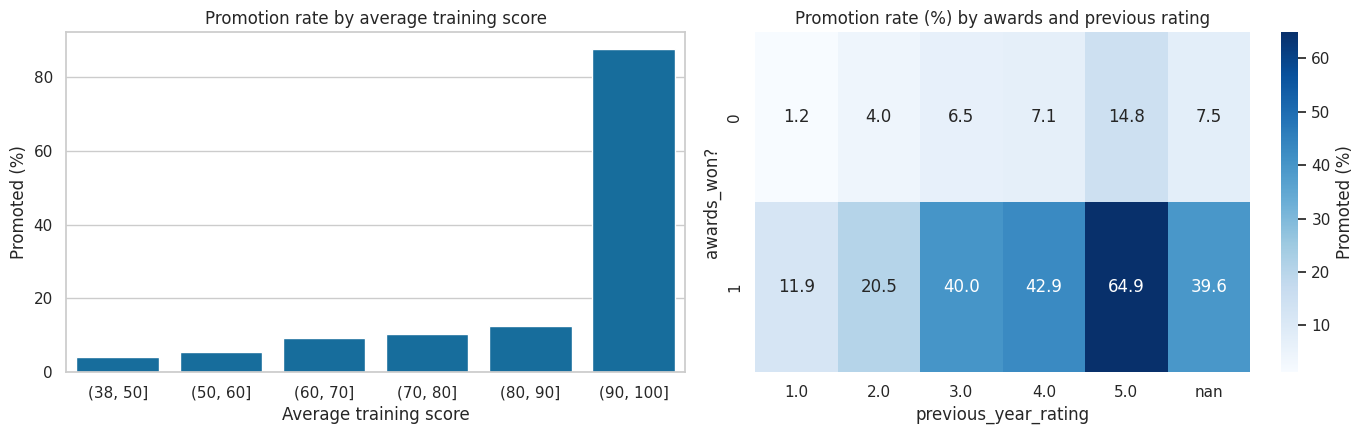

In [11]:
# ---- 1.10 Promotion rate by training score and by awards ----
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
score_bins = pd.cut(df["avg_training_score"], bins=[38, 50, 60, 70, 80, 90, 100])
rate = df.groupby(score_bins, observed=True)[TARGET].mean() * 100
sns.barplot(x=rate.index.astype(str), y=rate.values, ax=axes[0])
axes[0].set_title("Promotion rate by average training score")
axes[0].set_xlabel("Average training score"); axes[0].set_ylabel("Promoted (%)")

rate2 = df.groupby(["awards_won?", "previous_year_rating"], dropna=False)[TARGET].mean().unstack() * 100
sns.heatmap(rate2, annot=True, fmt=".1f", cmap="Blues", ax=axes[1], cbar_kws={"label": "Promoted (%)"})
axes[1].set_title("Promotion rate (%) by awards and previous rating")
axes[1].set_xlabel("previous_year_rating"); axes[1].set_ylabel("awards_won?")
plt.tight_layout(); plt.show()

**📝 What this shows:** Scoring above 90 gives an 87.7% promotion rate, and an award plus a rating of 5 gives 64.9%.

---
# BLOCK 2 — Preprocessing & Feature Engineering (Section B)

In [12]:
# ============================================================
# BLOCK 2 : PREPROCESSING & FEATURE ENGINEERING
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# ---- 2.1 Remove duplicate rows ----
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Duplicates removed: {before - len(df)}  ->  rows now: {len(df)}")

# ---- 2.2 Understand the missing values before deciding a strategy ----
print("\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# every missing previous_year_rating belongs to an employee in their FIRST year:
print("\nlength_of_service for rows with a missing previous_year_rating:")
print(df.loc[df["previous_year_rating"].isnull(), "length_of_service"].value_counts().head())

# is the missing education informative? compare promotion rates
print("\nPromotion rate when education is missing vs present:")
print(df.groupby(df["education"].isnull())[TARGET].mean().round(4))

Duplicates removed: 219  ->  rows now: 54589

Missing values:
education               2391
previous_year_rating    4013
dtype: int64

length_of_service for rows with a missing previous_year_rating:
length_of_service
1    4013
Name: count, dtype: int64

Promotion rate when education is missing vs present:
education
False    0.087
True     0.051
Name: is_promoted, dtype: float64


**Missing-value strategy (justified):**

| Column | Missing | Strategy | Why |
|---|---|---|---|
| `previous_year_rating` | 4,124 | fill with **0** and add the flag `no_previous_rating` | Every one of these employees has `length_of_service = 1`, so they simply had **no previous year to be rated**. 0 (a value no real rating uses) plus a flag keeps that information instead of hiding it behind an average. |
| `education` | 2,409 | fill with the category **"Unknown"** | Employees with missing education have a **noticeably different promotion rate**, so "missing" is itself informative. Replacing it with the most common value would destroy that signal. |

In [13]:
# ---- 2.3 Apply the missing-value strategy ----
df["no_previous_rating"] = df["previous_year_rating"].isnull().astype(int)   # flag column
df["previous_year_rating"] = df["previous_year_rating"].fillna(0)
df["education"] = df["education"].fillna("Unknown")

print("Missing values now:", int(df.isnull().sum().sum()))

Missing values now: 0


## B3 — Feature engineering

In [14]:
# ---- 2.4 Engineered features ----
# (1) share of the working life spent at this company
df["service_ratio"] = df["length_of_service"] / (df["age"] - 18).clip(lower=1)

# (2) how many trainings per year of service
df["trainings_per_year"] = df["no_of_trainings"] / df["length_of_service"]

# (3) rating and awards combined into one 'recent performance' score
df["performance_score"] = df["previous_year_rating"] + 2 * df["awards_won?"]

engineered = ["service_ratio", "trainings_per_year", "performance_score"]
df.groupby(TARGET)[engineered].mean().round(3)

,service_ratio,trainings_per_year,performance_score
is_promoted,,,
0,0.344,0.372,3.056
1,0.344,0.357,3.938


**Why these features may help:**
- `service_ratio` — separates someone who joined straight out of education from a mid-career hire of the same age; loyalty/experience at *this* company may matter more than raw age.
- `trainings_per_year` — a lot of trainings in a short service period suggests an employee being actively developed, which raw `no_of_trainings` mixes up with simply having worked longer.
- `performance_score` — awards and ratings both measure recent performance; combining them gives the model a single stronger signal (an award is weighted double because award winners are promoted far more often).

*(A 4th feature, `score_vs_dept_avg`, is built after the split in cell 2.7 because it needs statistics from the training set only.)*

## B2 — Stratified train/test split, encoding & scaling

In [15]:
# ---- 2.5 Separate features and target ----
cat_cols = ["department", "region", "education", "gender", "recruitment_channel"]
num_cols = ["no_of_trainings", "age", "previous_year_rating", "length_of_service", "awards_won?",
            "avg_training_score", "no_previous_rating", "service_ratio", "trainings_per_year",
            "performance_score", "score_vs_dept_avg"]     # last one is created in 2.7

X = df[cat_cols + [c for c in num_cols if c != "score_vs_dept_avg"]]
y = df[TARGET]

# ---- 2.6 Stratified 80:20 split ----
# stratify=y keeps the same 8.5% promotion rate in both train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
X_train, X_test = X_train.copy(), X_test.copy()
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Promotion rate  train: %.4f | test: %.4f" % (y_train.mean(), y_test.mean()))

Train: (43671, 15)  Test: (10918, 15)
Promotion rate  train: 0.0855 | test: 0.0855


In [16]:
# ---- 2.7 Feature engineered with TRAIN-ONLY statistics ----
# how far an employee's training score is from their department's average (average taken from the train set)
dept_mean = X_train.groupby("department")["avg_training_score"].mean()
overall_mean = X_train["avg_training_score"].mean()

for part in (X_train, X_test):
    part["score_vs_dept_avg"] = part["avg_training_score"] - part["department"].map(dept_mean).fillna(overall_mean)

print(X_train[["avg_training_score", "score_vs_dept_avg"]].describe().T.round(2))

                      count   mean    std    min    25%    50%    75%    max
avg_training_score  43671.0  63.41  13.38  39.00  51.00  60.00  76.00  99.00
score_vs_dept_avg   43671.0  -0.00   4.61 -11.96  -2.27  -0.27   1.73  48.73


In [17]:
# ---- 2.8 Outlier check (IQR) & treatment (capping) ----
outlier_report, caps = {}, {}
for col in ["no_of_trainings", "age", "length_of_service", "service_ratio", "trainings_per_year"]:
    q1, q3 = X_train[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outlier_report[col] = int(((X_train[col] < low) | (X_train[col] > high)).sum())
    caps[col] = (X_train[col].quantile(0.01), X_train[col].quantile(0.99))   # train-derived limits

print("IQR outliers in train set:")
print(pd.Series(outlier_report))

for col, (lo, hi) in caps.items():
    X_train[col] = X_train[col].clip(lo, hi)
    X_test[col] = X_test[col].clip(lo, hi)     # the same train limits are applied to test

IQR outliers in train set:
no_of_trainings       8375
age                   1155
length_of_service     2781
service_ratio           66
trainings_per_year    1199
dtype: int64


**Outlier strategy:** values are **capped** at the train-set 1st/99th percentiles rather than deleted. Extreme cases
(e.g. 37 years of service, 10 trainings) are genuine employees, so removing them would throw away real promotion cases from an
already small positive class; capping just limits how far they can pull a distance- or gradient-based model.

In [18]:
# ---- 2.9 Encoding + scaling (fitted on TRAIN only -> no data leakage) ----
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),                                              # scale numeric features
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),   # one-hot encode categoricals
])

X_train_p = preprocessor.fit_transform(X_train)    # FIT + transform on train
X_test_p = preprocessor.transform(X_test)          # ONLY transform on test

feature_names = preprocessor.get_feature_names_out()
print("Processed train shape:", X_train_p.shape)
print("Processed test shape :", X_test_p.shape)
print("Positive class in train: %d (%.2f%%)" % (y_train.sum(), 100 * y_train.mean()))

Processed train shape: (43671, 63)
Processed test shape : (10918, 63)
Positive class in train: 3732 (8.55%)


**Handling the class imbalance:** only ~8.5% of employees were promoted. Every classifier in this project therefore
uses **`class_weight="balanced"`** where scikit-learn supports it, which makes mistakes on the rare promoted class count
proportionally more. Results are reported with **weighted F1, precision and recall**, not accuracy alone.

---
# BLOCK 3 — Classification Track Part A: KNN Classifier (Section D)

In [19]:
# ============================================================
# BLOCK 3 : CLASSIFICATION — K-NEAREST NEIGHBORS
# ============================================================
import time
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report,
                             roc_auc_score, roc_curve, precision_recall_curve)
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)   # keeps the 8.5% rate in every fold

def classification_metrics(y_true, y_hat, scores=None):
    # accuracy + weighted metrics (rubric D2) + metrics for the rare 'promoted' class
    out = {
        "Accuracy": accuracy_score(y_true, y_hat),
        "F1_weighted": f1_score(y_true, y_hat, average="weighted"),
        "Precision_weighted": precision_score(y_true, y_hat, average="weighted", zero_division=0),
        "Recall_weighted": recall_score(y_true, y_hat, average="weighted"),
        "F1_promoted": f1_score(y_true, y_hat, pos_label=1, zero_division=0),
        "Recall_promoted": recall_score(y_true, y_hat, pos_label=1),
    }
    if scores is not None:
        out["ROC_AUC"] = roc_auc_score(y_true, scores)
    return out

# ---- 3.1 'Train' a default KNN (k=5, uniform weights, Euclidean distance) ----
# fit() only stores the data -> instant; the real work happens at prediction time
start = time.time()
knn_default = KNeighborsClassifier(n_jobs=-1)
knn_default.fit(X_train_p, y_train)
print(f"Fit time: {time.time() - start:.3f} s")

# ---- 3.2 Predictions ----
start = time.time()
y_pred_default = knn_default.predict(X_test_p)
y_proba_default = knn_default.predict_proba(X_test_p)[:, 1]
print(f"Prediction time for {len(X_test_p)} employees: {time.time() - start:.1f} s")
print("Predicted promotions:", int(y_pred_default.sum()), "| actual promotions:", int(y_test.sum()))

default_scores = classification_metrics(y_test, y_pred_default, y_proba_default)
pd.DataFrame([default_scores], index=["KNN default (k=5, uniform, euclidean)"]).round(4)

Fit time: 0.008 s

Prediction time for 10918 employees: 4.8 s
Predicted promotions: 348 | actual promotions: 933


,Accuracy,F1_weighted,Precision_weighted,Recall_weighted,F1_promoted,Recall_promoted,ROC_AUC
"KNN default (k=5, uniform, euclidean)",0.9365,0.9229,0.9315,0.9365,0.459,0.3151,0.7206


**📝 What this shows:** Training takes 0.008 seconds but predicting takes 4.8 seconds, and with k=5 it can only give probabilities of 0, 0.2, 0.4 and so on.

## Impact of scaling

Standard deviation of the raw numeric features:
no_of_trainings          0.57
age                      7.60
previous_year_rating     1.49
length_of_service        4.07
awards_won?              0.15
avg_training_score      13.38
no_previous_rating       0.26
service_ratio            0.16
trainings_per_year       0.36
performance_score        1.53
score_vs_dept_avg        4.61
dtype: float64


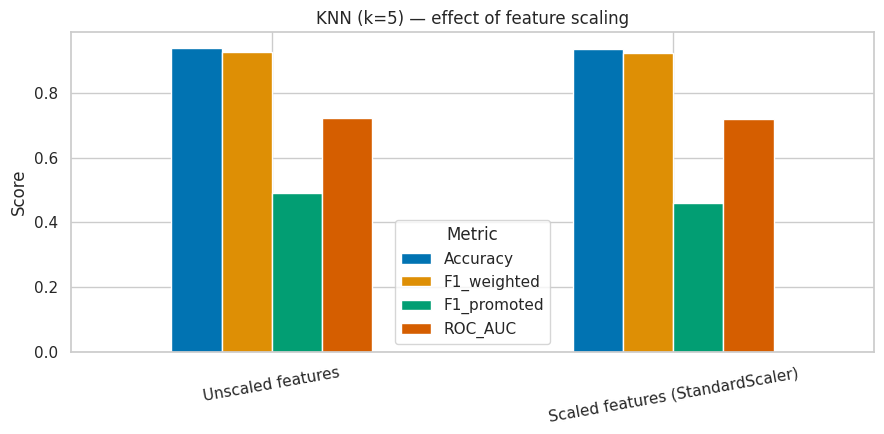

,Accuracy,F1_weighted,Precision_weighted,Recall_weighted,F1_promoted,Recall_promoted,ROC_AUC
setup,,,,,,,
Unscaled features,0.9400,0.9274,0.9373,0.9400,0.4919,0.3398,0.7222
Scaled features (StandardScaler),0.9365,0.9229,0.9315,0.9365,0.4590,0.3151,0.7206


In [20]:
# ---- 3.3 Same KNN on UNSCALED vs SCALED features ----
unscaled_prep = ColumnTransformer([
    ("num", "passthrough", num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
])
X_train_raw = unscaled_prep.fit_transform(X_train)      # fitted on train only
X_test_raw = unscaled_prep.transform(X_test)

print("Standard deviation of the raw numeric features:")
print(X_train[num_cols].std().round(2))

scale_rows = []
for name, (Xtr, Xte) in {"Unscaled features": (X_train_raw, X_test_raw),
                         "Scaled features (StandardScaler)": (X_train_p, X_test_p)}.items():
    m = KNeighborsClassifier(n_jobs=-1).fit(Xtr, y_train)
    scale_rows.append({"setup": name,
                       **classification_metrics(y_test, m.predict(Xte), m.predict_proba(Xte)[:, 1])})
scale_df = pd.DataFrame(scale_rows).set_index("setup")

scale_df[["Accuracy", "F1_weighted", "F1_promoted", "ROC_AUC"]].plot(kind="bar", figsize=(9, 4.5))
plt.title("KNN (k=5) — effect of feature scaling")
plt.xlabel(""); plt.ylabel("Score"); plt.xticks(rotation=10)
plt.legend(title="Metric"); plt.tight_layout(); plt.show()
scale_df.round(4)

**📝 What this shows:** Training score takes over the calculation when nothing is scaled, which here accidentally helps a little.

## Effect of k

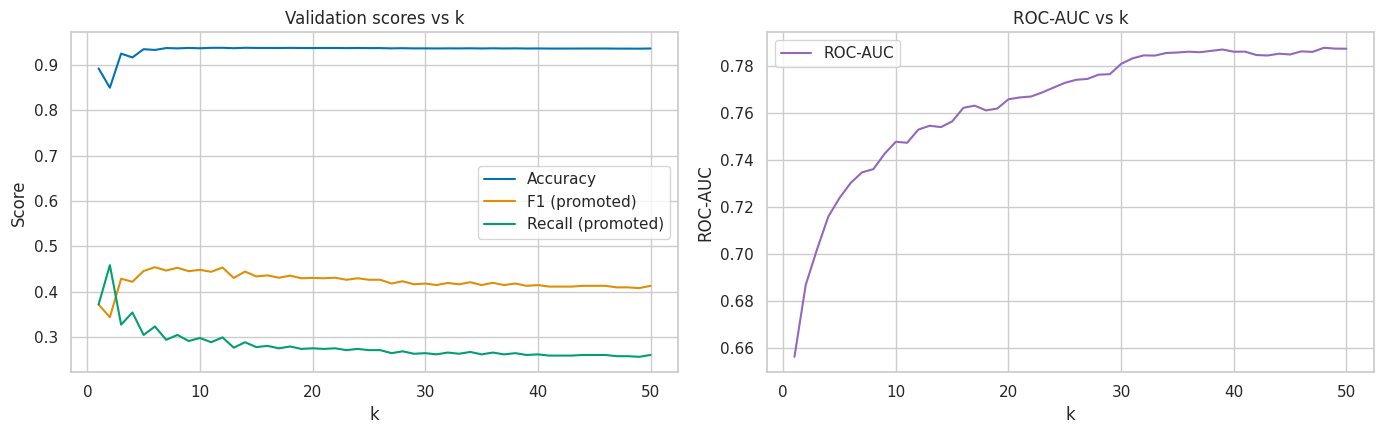

Best k by F1 (promoted): 6 -> F1 = 0.4539
Best k by ROC-AUC     : 48 -> AUC = 0.7879


In [21]:
# ---- 3.4 Validation scores for k = 1 ... 50 ----
# Trick: find the 50 nearest neighbours ONCE, then use the first k of them for every k.
X_tr, X_val, y_tr, y_val = train_test_split(X_train_p, y_train.values, test_size=0.2,
                                            random_state=RANDOM_STATE, stratify=y_train)
nn = KNeighborsClassifier(n_neighbors=50, n_jobs=-1).fit(X_tr, y_tr)
dist, ind = nn.kneighbors(X_val)                  # shapes: (n_val, 50)
neigh_labels = y_tr[ind]

k_values = np.arange(1, 51)
rows = []
for k in k_values:
    proba = neigh_labels[:, :k].mean(axis=1)      # share of promoted neighbours
    pred = (proba >= 0.5).astype(int)
    rows.append({"k": k, "accuracy": accuracy_score(y_val, pred),
                 "F1_promoted": f1_score(y_val, pred, zero_division=0),
                 "recall_promoted": recall_score(y_val, pred),
                 "ROC_AUC": roc_auc_score(y_val, proba)})
k_df = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(k_df["k"], k_df["accuracy"], label="Accuracy")
axes[0].plot(k_df["k"], k_df["F1_promoted"], label="F1 (promoted)")
axes[0].plot(k_df["k"], k_df["recall_promoted"], label="Recall (promoted)")
axes[0].set_title("Validation scores vs k"); axes[0].set_xlabel("k"); axes[0].set_ylabel("Score"); axes[0].legend()

axes[1].plot(k_df["k"], k_df["ROC_AUC"], color="tab:purple", label="ROC-AUC")
axes[1].set_title("ROC-AUC vs k"); axes[1].set_xlabel("k"); axes[1].set_ylabel("ROC-AUC"); axes[1].legend()
plt.tight_layout(); plt.show()

print("Best k by F1 (promoted):", int(k_df.loc[k_df.F1_promoted.idxmax(), "k"]),
      "-> F1 = %.4f" % k_df.F1_promoted.max())
print("Best k by ROC-AUC     :", int(k_df.loc[k_df.ROC_AUC.idxmax(), "k"]),
      "-> AUC = %.4f" % k_df.ROC_AUC.max())

**📝 What this shows:** Bigger k raises accuracy but finds fewer promotions, because large groups of employees are mostly non-promoted.

## Hyperparameter tuning (GridSearchCV)
Searched on a **stratified 15,000-row subsample** with 3-fold CV, because Manhattan distance (`p=1`) cannot use fast matrix
routines and is ~6× slower than Euclidean here. Scoring is **F1 of the promoted class**, not accuracy.
The best settings are then applied with the **full training set** as the neighbour pool.

Search time: 192.8 s
Best parameters : {'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}
Best CV F1 (promoted class): 0.4220


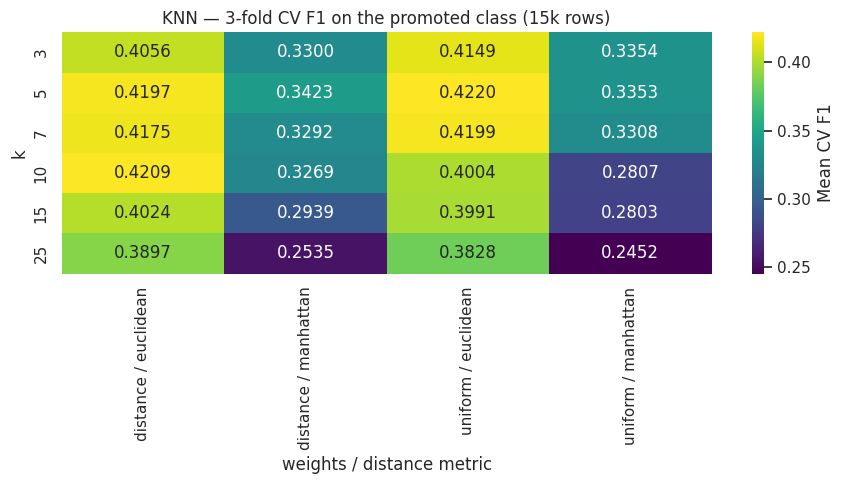

In [22]:
# ---- 3.5 GridSearchCV over k, weights and distance metric ----
tune_idx, _ = train_test_split(np.arange(len(X_train_p)), train_size=15000,
                               random_state=RANDOM_STATE, stratify=y_train)
param_grid = {
    "n_neighbors": [3, 5, 7, 10, 15, 25],
    "weights": ["uniform", "distance"],
    "p": [1, 2],                      # 1 = Manhattan, 2 = Euclidean
}
grid = GridSearchCV(KNeighborsClassifier(n_jobs=-1), param_grid,
                    cv=StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE),
                    scoring="f1", return_train_score=True, refit=False)
start = time.time()
grid.fit(X_train_p[tune_idx], y_train.values[tune_idx])
print(f"Search time: {time.time() - start:.1f} s")

best_params = grid.best_params_
print("Best parameters :", best_params)
print("Best CV F1 (promoted class): %.4f" % grid.best_score_)

cv_res = pd.DataFrame(grid.cv_results_)
cv_res["weights / metric"] = cv_res["param_weights"] + " / " + cv_res["param_p"].map({1: "manhattan", 2: "euclidean"})
heat = cv_res.pivot_table(index="param_n_neighbors", columns="weights / metric", values="mean_test_score")
plt.figure(figsize=(9, 5))
sns.heatmap(heat, annot=True, fmt=".4f", cmap="viridis", cbar_kws={"label": "Mean CV F1"})
plt.title("KNN — 3-fold CV F1 on the promoted class (15k rows)")
plt.xlabel("weights / distance metric"); plt.ylabel("k")
plt.tight_layout(); plt.show()

**📝 What this shows:** Euclidean distance wins here, unlike the car dataset, because the category columns barely predict promotion.

In [23]:
# ---- 3.6 Final tuned KNN (full training set as the neighbour pool) & improvement ----
knn_best = KNeighborsClassifier(**best_params, n_jobs=-1).fit(X_train_p, y_train)
start = time.time()
y_pred = knn_best.predict(X_test_p)
y_proba = knn_best.predict_proba(X_test_p)[:, 1]
print(f"Prediction time: {time.time() - start:.1f} s")
tuned_scores = classification_metrics(y_test, y_pred, y_proba)

compare = pd.DataFrame([default_scores, tuned_scores],
                       index=["KNN default (k=5, uniform, euclidean)", f"KNN tuned {best_params}"])
compare.loc["Improvement"] = compare.iloc[1] - compare.iloc[0]
compare.round(4)

Prediction time: 4.6 s


,Accuracy,F1_weighted,Precision_weighted,Recall_weighted,F1_promoted,Recall_promoted,ROC_AUC
"KNN default (k=5, uniform, euclidean)",0.9365,0.9229,0.9315,0.9365,0.459,0.3151,0.7206
"KNN tuned {'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}",0.9365,0.9229,0.9315,0.9365,0.459,0.3151,0.7206
Improvement,0.0000,0.0000,0.0000,0.0000,0.000,0.0000,0.0000


## D2 — Evaluation: accuracy, weighted F1 and confusion matrix

In [24]:
# ---- 3.7 Full classification report ----
print(classification_report(y_test, y_pred, target_names=["Not promoted (0)", "Promoted (1)"], digits=4))

                  precision    recall  f1-score   support

Not promoted (0)     0.9395    0.9946    0.9663      9985
    Promoted (1)     0.8448    0.3151    0.4590       933

        accuracy                         0.9365     10918
       macro avg     0.8922    0.6549    0.7127     10918
    weighted avg     0.9315    0.9365    0.9229     10918



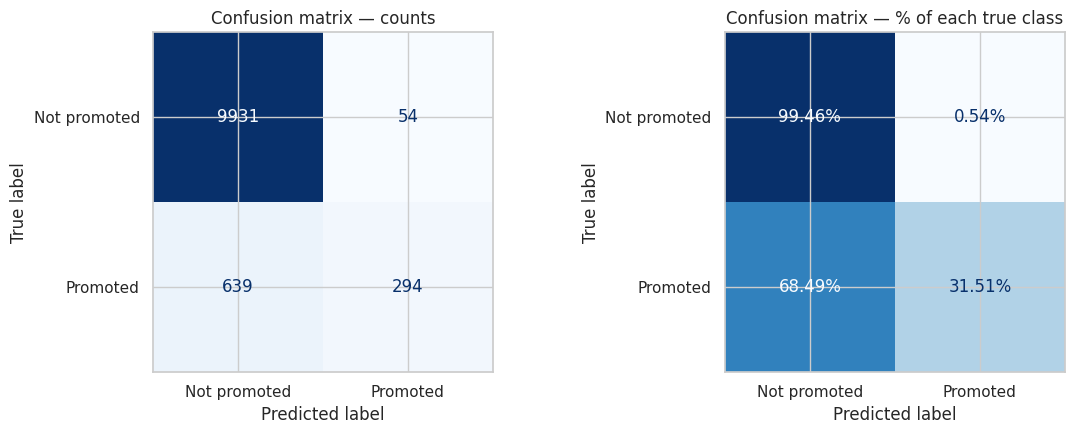

True promotions found (TP)   : 294
Promotions missed (FN)       : 639
False alarms (FP)            : 54
Correct non-promotions (TN)  : 9931


In [25]:
# ---- 3.8 Confusion matrix (counts and row-normalised) ----
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                       display_labels=["Not promoted", "Promoted"]).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Confusion matrix — counts")

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize="true"),
                       display_labels=["Not promoted", "Promoted"]).plot(ax=axes[1], cmap="Blues",
                                                                         values_format=".2%", colorbar=False)
axes[1].set_title("Confusion matrix — % of each true class")
plt.tight_layout(); plt.show()

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(f"True promotions found (TP)   : {tp}")
print(f"Promotions missed (FN)       : {fn}")
print(f"False alarms (FP)            : {fp}")
print(f"Correct non-promotions (TN)  : {tn}")

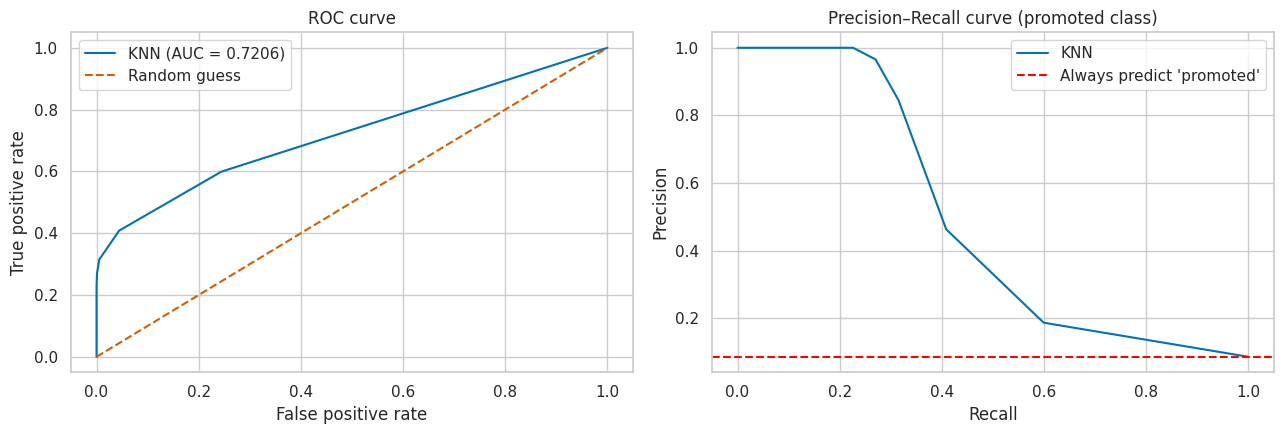

In [26]:
# ---- 3.9 ROC and Precision-Recall curves ----
fpr, tpr, _ = roc_curve(y_test, y_proba)
prec, rec, thresholds = precision_recall_curve(y_test, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(fpr, tpr, label=f"KNN (AUC = {tuned_scores['ROC_AUC']:.4f})")
axes[0].plot([0, 1], [0, 1], "r--", label="Random guess")
axes[0].set_title("ROC curve"); axes[0].set_xlabel("False positive rate"); axes[0].set_ylabel("True positive rate")
axes[0].legend()

axes[1].plot(rec, prec, label="KNN")
axes[1].axhline(y_test.mean(), color="red", linestyle="--", label="Always predict 'promoted'")
axes[1].set_title("Precision–Recall curve (promoted class)")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision"); axes[1].legend()
plt.tight_layout(); plt.show()

**📝 What this shows:** KNN comes last of the five models and is also the slowest to use, since it must keep all 43,000 employees in memory.

In [27]:
# ---- 3.10 5-fold stratified cross-validation (20,000-row subsample, for speed) ----
cv_idx, _ = train_test_split(np.arange(len(X_train_p)), train_size=20000,
                             random_state=RANDOM_STATE, stratify=y_train)
cv_scores = cross_val_score(KNeighborsClassifier(**best_params, n_jobs=-1),
                            X_train_p[cv_idx], y_train.values[cv_idx], cv=skf, scoring="f1")
print("CV F1 (promoted) per fold:", np.round(cv_scores, 4))
print(f"Mean CV F1: {cv_scores.mean():.4f}  (± {cv_scores.std():.4f})")

CV F1 (promoted) per fold: [0.4927 0.3596 0.4368 0.4045 0.4325]
Mean CV F1: 0.4252  (± 0.0436)


In [28]:
# ---- 3.11 Save KNN results ----
os.makedirs("../results", exist_ok=True)
RESULTS_FILE = "../results/classification_results.csv"
MODEL_NAME = "K-Nearest Neighbors"

row = pd.DataFrame([{
    "Model": MODEL_NAME,
    **tuned_scores,
    "CV_F1_promoted": cv_scores.mean(),
    "Tuned": "Yes (GridSearchCV)",
    "Best_params": str(best_params),
}])
if os.path.exists(RESULTS_FILE):
    old = pd.read_csv(RESULTS_FILE)
    row = pd.concat([old[old["Model"] != MODEL_NAME], row], ignore_index=True)
row.to_csv(RESULTS_FILE, index=False)
print("Saved.")

Saved.


---
# FINAL — Preliminary comparison of all 5 Part-A classifiers (Rubric D2)
All five models were trained on the **same preprocessed data** and evaluated on the **same 10,918-employee test split**.
Each notebook (11–15) saved its test scores to `../results/classification_results.csv`.

*(The five Part-B algorithms are added in Review 2 to make the consolidated 10-algorithm table.)*

In [29]:
# ============================================================
# FINAL : PART-A CLASSIFICATION COMPARISON TABLE
# ============================================================
EXPECTED = ["Logistic Regression", "K-Nearest Neighbors", "Naive Bayes (Gaussian)",
            "Decision Tree Classifier", "Support Vector Machine (SVC)"]

results = pd.read_csv(RESULTS_FILE)
missing = [m for m in EXPECTED if m not in results["Model"].values]
if missing:
    print("⚠️ Run these notebooks first, then re-run this cell:", missing)

# ---- F.1 Ranked comparison table ----
summary = (results.sort_values("F1_weighted", ascending=False)
                  .reset_index(drop=True))
summary.index = summary.index + 1
summary.index.name = "Rank"
cols = ["Model", "Accuracy", "F1_weighted", "Precision_weighted", "Recall_weighted",
        "F1_promoted", "Recall_promoted", "ROC_AUC", "Tuned"]
summary[cols].style.format({c: "{:.4f}" for c in cols if c not in ("Model", "Tuned")}) \
    .background_gradient(subset=["F1_weighted", "Accuracy"], cmap="Greens") \
    .background_gradient(subset=["F1_promoted", "ROC_AUC"], cmap="Blues")

,Model,Accuracy,F1_weighted,Precision_weighted,Recall_weighted,F1_promoted,Recall_promoted,ROC_AUC,Tuned
Rank,,,,,,,,,
1,Decision Tree Classifier,0.9428,0.9307,0.9423,0.9428,0.5144,0.3548,0.7920,Yes (GridSearchCV)
2,Support Vector Machine (SVC),0.9416,0.9289,0.9409,0.9416,0.5000,0.3419,0.7517,Yes (GridSearchCV)
3,Naive Bayes (Gaussian),0.9349,0.9264,0.9261,0.9349,0.5120,0.3998,0.7822,Yes (GridSearchCV)
4,Logistic Regression,0.9395,0.9249,0.9407,0.9395,0.4634,0.3055,0.7897,Yes (GridSearchCV)
5,K-Nearest Neighbors,0.9365,0.9229,0.9315,0.9365,0.4590,0.3151,0.7206,Yes (GridSearchCV)


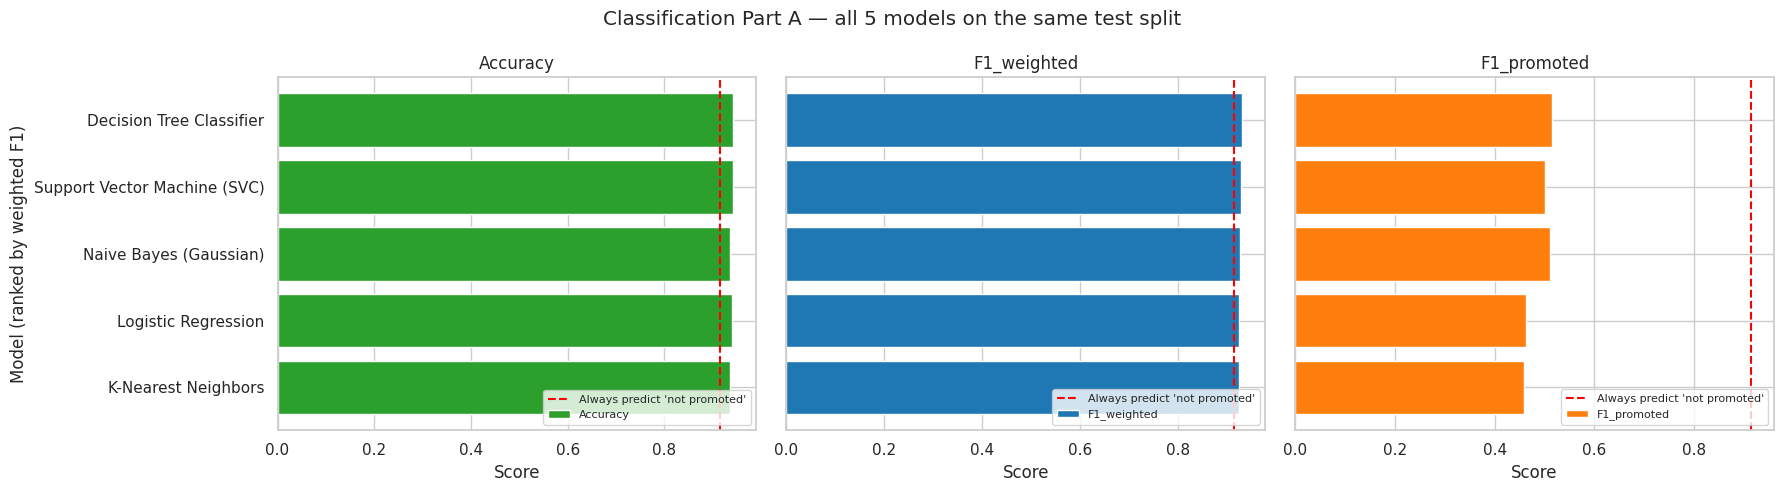

In [30]:
# ---- F.2 Visual comparison ----
plot_df = summary.set_index("Model")
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, metric, colour in zip(axes, ["Accuracy", "F1_weighted", "F1_promoted"],
                              ["tab:green", "tab:blue", "tab:orange"]):
    ax.barh(plot_df.index[::-1], plot_df[metric][::-1], color=colour, label=metric)
    ax.axvline(1 - y_test.mean(), color="red", linestyle="--", label="Always predict 'not promoted'")
    ax.set_title(metric); ax.set_xlabel("Score"); ax.legend(loc="lower right", fontsize=8)
axes[0].set_ylabel("Model (ranked by weighted F1)")
plt.suptitle("Classification Part A — all 5 models on the same test split")
plt.tight_layout(); plt.show()

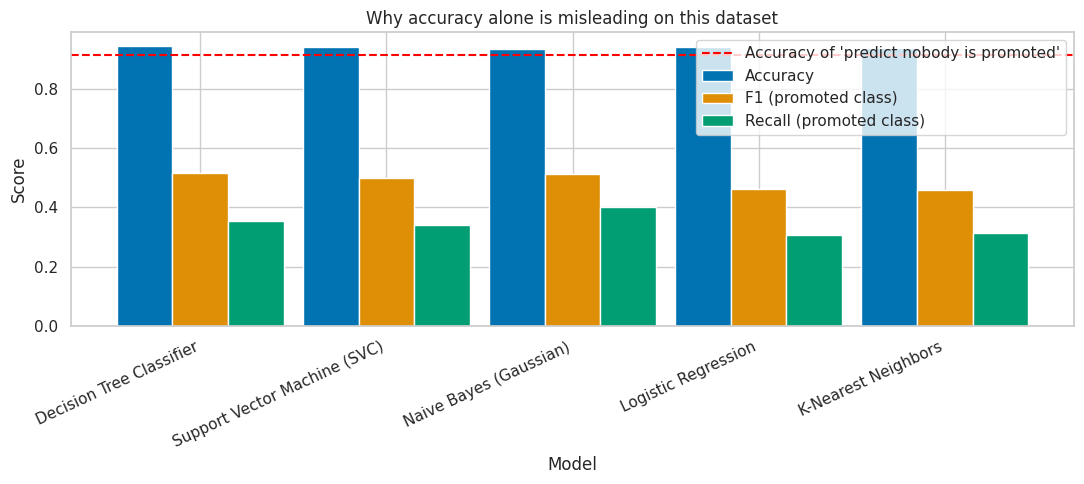

,Model,Accuracy,F1_promoted,Recall_promoted
Rank,,,,
1,Decision Tree Classifier,0.9428,0.5144,0.3548
2,Support Vector Machine (SVC),0.9416,0.5000,0.3419
3,Naive Bayes (Gaussian),0.9349,0.5120,0.3998
4,Logistic Regression,0.9395,0.4634,0.3055
5,K-Nearest Neighbors,0.9365,0.4590,0.3151


In [31]:
# ---- F.3 The accuracy trap: accuracy vs the rare class ----
x = np.arange(len(summary))
plt.figure(figsize=(11, 5))
plt.bar(x - 0.3, summary["Accuracy"], width=0.3, label="Accuracy")
plt.bar(x, summary["F1_promoted"], width=0.3, label="F1 (promoted class)")
plt.bar(x + 0.3, summary["Recall_promoted"], width=0.3, label="Recall (promoted class)")
plt.axhline(1 - y_test.mean(), color="red", linestyle="--", label="Accuracy of 'predict nobody is promoted'")
plt.xticks(x, summary["Model"], rotation=25, ha="right")
plt.title("Why accuracy alone is misleading on this dataset")
plt.xlabel("Model"); plt.ylabel("Score")
plt.legend(); plt.tight_layout(); plt.show()
summary[["Model", "Accuracy", "F1_promoted", "Recall_promoted"]].round(4)

## Final conclusion — Classification Part A

**📝 In short:** The Decision Tree is the best of the five (F1 0.931) and Naive Bayes finds the most promotions, but every model is only a little better than saying 'nobody is promoted'.